<a href="https://colab.research.google.com/github/HafizaNoorUlSaba/langgraph/blob/Chatbot-with-memory/Customer_Support_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Install Libraries***

In [1]:
!pip install -q -U langgraph
!pip install -q -U langchain
!pip install -q -U langchain-core
!pip install -q -U langchain-google-genai
!pip install -q -U langgraph-checkpoint
!pip install -q -U grandalf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.9 MB/s eta 0:00:00


***Import Libraries***

In [2]:
import os

from typing import TypedDict
from typing import Annotated

from langgraph.graph import StateGraph, START, END

from langgraph.graph.message import add_messages

from langchain_core.messages import AnyMessage
from langchain_core.messages import HumanMessage
from langchain_core.messages import AIMessage

from langchain_google_genai import ChatGoogleGenerativeAI

In [3]:


import os
from google.colab import userdata
Google_Api_Key_from_secrets = userdata.get('Google_Api_Key')

if Google_Api_Key_from_secrets:
    os.environ['Google_Api_Key'] = Google_Api_Key_from_secrets
    print("Google_Api_Key loaded from Colab secrets.")
else:
    print("Warning: Google_Api_Key secret not found in Colab secrets. Please ensure it's set correctly.")

Google_Api_Key loaded from Colab secrets.


***Initialize LLM***

In [4]:
llm = ChatGoogleGenerativeAI(
    google_api_key=os.environ.get('Google_Api_Key'),
    model="gemini-2.5-flash",
    temperature=0
)
model=llm

***Create State***

In [5]:
class AgentState(TypedDict):
  messages: Annotated
  list :[AnyMessage]
  add_messages


***AI Node***

In [6]:
def chatbot(state: AgentState):

    response = llm.invoke(
        state["messages"]
    )

    return {

        "messages":[
            AIMessage(
                content=response.content
            )
        ]

    }

In [7]:
add_messages

<function langgraph.graph.message._add_messages_wrapper.<locals>._add_messages(left: 'Messages | None' = None, right: 'Messages | None' = None, **kwargs: 'Any') -> 'Messages | Callable[[Messages, Messages], Messages]'>

***Build Graph***

In [8]:
builder = StateGraph(AgentState)

***Add Nodes and Edges***

In [9]:
builder.add_node(
    "chatbot",
    chatbot
)
builder.add_edge(
    START,
    "chatbot"
)

builder.add_edge(
    "chatbot",
    END
)

***Compile Graph***

In [10]:
app = builder.compile()

***Draw Graph***

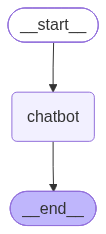

In [11]:
from IPython.display import Image
from IPython.display import display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [12]:
response = app.invoke(

    {

        "messages":[

            HumanMessage(
                content="Hello"
            )

        ]

    }

)

print(
    response["messages"][-1].content
)

Hello! How can I help you today?


In [13]:
response = app.invoke(

    {

        "messages":[

            HumanMessage(
                content="What is LangGraph?"
            )

        ]

    }

)

print(
    response["messages"][-1].content
)

**LangGraph** is a library built on top of LangChain that allows you to build **stateful, cyclic graphs** for your Language Model (LLM) applications.

Think of it as a powerful orchestration layer that enables you to define complex, multi-step workflows where an AI agent can make decisions, use tools, iterate, and even self-correct.

Here's a breakdown of what that means and why it's important:

### The Problem LangGraph Solves

Traditional LLM chains (even in LangChain) are often linear or tree-like. They execute a sequence of steps and then finish. However, many real-world AI agent behaviors require:

1.  **Iteration/Loops:** Trying something, observing the result, and trying again if it's not good enough.
2.  **Self-Correction:** Realizing a mistake or a dead end and going back to a previous step to try a different approach.
3.  **Complex Decision Making:** Dynamically choosing the next action based on the current state and observations.
4.  **State Management:** Maintaining context

***Add Memory and Persistant Memory***

In [14]:
conversation = []

conversation.append(
    HumanMessage(
        content="Hello"
    )
)

response = app.invoke(
    {
        "messages": conversation
    }
)

conversation = response["messages"]

print(
    conversation[-1].content
)

Hello! How can I help you today?


In [15]:
conversation.append(
    HumanMessage(
        content="My name is Noor."
    )
)

response = app.invoke(
    {
        "messages": conversation
    }
)

conversation = response["messages"]

print(
    conversation[-1].content
)

Hello Noor, it's nice to meet you! How can I help you today?


In [16]:
conversation.append(
    HumanMessage(
        content="What is my name?"
    )
)

response = app.invoke(
    {
        "messages": conversation
    }
)

conversation = response["messages"]

print(
    conversation[-1].content
)

Ah, my apologies! I used "Noor" in my greeting because that was the name provided to me in the context of our conversation.

However, I don't actually know your real name unless you tell me. What would you like me to call you?


***Print Memory***

In [17]:
for msg in conversation:

    print(type(msg).__name__)

    print(msg.content)

    print("-"*50)

AIMessage
Ah, my apologies! I used "Noor" in my greeting because that was the name provided to me in the context of our conversation.

However, I don't actually know your real name unless you tell me. What would you like me to call you?
--------------------------------------------------


In [18]:
conversation = []

while True:

    question = input("You: ")

    if question.lower() == "exit":
        break

    conversation.append(
        HumanMessage(content=question)
    )

    result = app.invoke(
        {
            "messages": conversation
        }
    )

    conversation = result["messages"]

    print(
        "AI:",
        conversation[-1].content
    )

You: what is agentic ai
AI: **Agentic AI** refers to Artificial Intelligence systems that are designed to act as autonomous "agents" in pursuit of a specific goal. Unlike traditional AI models that might perform a single, reactive task (like answering a question or classifying an image), agentic AI systems are proactive, capable of breaking down complex goals into smaller steps, executing those steps, observing the results, and adapting their plan based on feedback, all without constant human intervention.

Think of it as an AI that doesn't just *tell* you how to do something, but actually *does* it.

### Key Characteristics of Agentic AI:

1.  **Goal-Oriented:** They are given a high-level objective (e.g., "Plan a trip to Paris for next month," "Develop a simple Python script to analyze this data," "Research the best marketing strategies for a new product").
2.  **Planning:** They can decompose a complex goal into a sequence of manageable sub-tasks.
3.  **Execution/Action:** They can 